In [1]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context


import pandas as pd
import numpy as np
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/amankharwal/Website-data/master/gold_price.csv")
df.head()

,Date,USD (AM),USD (PM),GBP (AM),GBP (PM),EURO (AM),EURO (PM)
0,2001-01-02,272.80,271.10,183.026,181.617,288.677,287.334
1,2001-01-03,269.00,267.15,178.916,177.390,281.823,281.655
2,2001-01-04,268.75,267.10,178.869,178.352,282.538,282.049
3,2001-01-05,268.00,267.40,178.488,178.148,280.775,280.882
4,2001-01-08,268.60,268.30,178.769,178.664,282.410,282.481


In [3]:

df['Return'] = df['USD (PM)'].pct_change() * 100
df['Lagged_Return'] = df.Return.shift()
df = df.dropna()
train = df.loc[0:4000]
test = df.loc[4000:4662]

In [4]:
x_train = train['Lagged_Return'].to_frame()
x_test = test['Lagged_Return'].to_frame()
y_train = train['Return']
y_test = test['Return']
x_train.head()


,Lagged_Return
2,-1.457027
3,-0.018716
4,0.112317
5,0.336574
6,-0.484532


In [5]:
model = LinearRegression()
model.fit(x_train,y_train)
pred = model.predict(x_test)

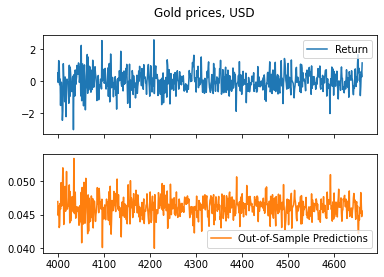

In [8]:
import matplotlib.pyplot as plt
out_of_sample_results = y_test.to_frame()
# Add a column of "out-of-sample" predictions to that dataframe:  
out_of_sample_results["Out-of-Sample Predictions"] = model.predict(x_test)
out_of_sample_results.plot(subplots=True, title='Gold prices, USD')
plt.show()